# **YOLO 파인튜닝**

# 1.환경준비

## (1) 라이브러리 설치

In [2]:
!pip install roboflow -q

ERROR: Could not install packages due to an OSError: [WinError 5] 액세스가 거부되었습니다: 'C:\\Users\\USER\\anaconda3\\envs\\aivle_pytorch\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



## (2) 라이브러리 불러오기

In [7]:
from ultralytics import settings, YOLO
from roboflow import Roboflow
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video

* 폴더 내 이미지 개수 확인

In [8]:
def image_count(path) :
    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

    # valid 폴더에서 이미지 파일 개수 확인
    image_count = len([f for f in os.listdir(path) if f.lower().endswith(tuple(image_extensions))])

    return image_count

## (3) YOLO 설정

* 파일 경로 설정

In [3]:
# 현재 세팅을 확인해 봅시다.
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': 'e93724c3a62b829fe2022931d0c4e07c6e9e5bbc21bb08e52bb2b401c0a189fa',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

In [4]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = './data/'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': './data/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': 'e93724c3a62b829fe2022931d0c4e07c6e9e5bbc21bb08e52bb2b401c0a189fa',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델링

## (1) 데이터셋 다운로드

![](https://i.imgur.com/xIudTbe.png)

* 아래 링크를 눌러 데이터셋 다운로드 코드를 받아 옵시다.

    - **[링크](https://universe.roboflow.com/roboflow-58fyf/rock-paper-scissors-sxsw)**

In [ ]:
rf = Roboflow(api_key="") # 개인별 api key값을 넣습니다.
project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
version = project.version(14)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rock-paper-scissors-14 in yolov11:: 100%|██████████| 14682/14682 [00:07<00:00, 1989.58it/s]


* 이미지 개수 확인

In [8]:
# train 이미지
cnt = image_count('./rock-paper-scissors-14/train/images')
print('* train 이미지 수 :', cnt)

# valid 이미지
cnt = image_count('./rock-paper-scissors-14/valid/images')
print('* valid 이미지 수 :', cnt)

# test 이미지
cnt = image_count('./rock-paper-scissors-14/test/images')
print('* test 이미지 수 :', cnt)

* train 이미지 수 : 6455
* valid 이미지 수 : 576
* test 이미지 수 : 304


## (2) 모델

### 1) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [9]:
model = YOLO(model='yolo11n.pt', task='detect')

### 2) 모델 살펴보기

**다음 내용은 참조하세요.**
* Backbone : CNN 기반 특징 추출기 (0~9)
    * 입력 이미지를 받아서 엣지, 텍스처, 형태 같은 저수준~중간 수준의 특징을 뽑음.
    * 보통 Conv, C3 블록, SPPF 같은 모듈이 포함됨.
    * YOLO 에서 0~9번 레이어 (Conv → C3k2 → … → SPPF) 가 여기에 해당
* Neck : 다중 스케일 특징 결합기 (10~22)
    * 여러 단계의 feature map을 서로 결합해서 더 풍부한 표현을 만듦.
    * FPN이나 PAN 구조를 써서 작은 물체부터 큰 물체까지 다 잡을 수 있도록 함.
    * Upsample, Concat, C3k2 같은 블록들이 여기에 해당 (10~22번).
* Head : 최종 예측기 (23)
    * 실제로 bounding box 좌표와 클래스 확률을 출력하는 부분.
    * YOLO에서는 Detect 모듈 (23번)이 여기에 해당.

* 요약 정보 (레이어 수, 파라미터 수 등)

In [10]:
model.info()

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

* 모델 블록 단위 확인하기
    * 블록 안에 하위 레이어들이 포함된다.

In [11]:
# 레이어 구조 확인
for i, m in enumerate(model.model.model):
    print(f"{i:3d} : {m.__class__.__name__}")

  0 : Conv
  1 : Conv
  2 : C3k2
  3 : Conv
  4 : C3k2
  5 : Conv
  6 : C3k2
  7 : Conv
  8 : C3k2
  9 : SPPF
 10 : C2PSA
 11 : Upsample
 12 : Concat
 13 : C3k2
 14 : Upsample
 15 : Concat
 16 : C3k2
 17 : Conv
 18 : Concat
 19 : C3k2
 20 : Conv
 21 : Concat
 22 : C3k2
 23 : Detect


* 전체 네트워크 아키텍처 출력

In [12]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

## (3) 파인튜닝

* 모델 학습
    * 파라미터 설명 : [Parameters](https://docs.ultralytics.com/modes/train/#train-settings)

In [14]:
results_train = model.train(model='./yolov11n.pt',
                            data='./rock-paper-scissors-14/data.yaml',
                            epochs=3,
                            seed=20,
                            optimizer = 'Adam',
                            pretrained=True,
                            lr0 = 0.0001
                            )

Ultralytics 8.3.225  Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./yolov11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, perspective=0.

In [15]:
valid_folder = "./rock-paper-scissors-14/valid/images"  # valid 폴더 경로 지정
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

# valid 폴더에서 이미지 파일 개수 확인
image_count = len([f for f in os.listdir(valid_folder) if f.lower().endswith(tuple(image_extensions))])

print(f"Valid 폴더의 이미지 개수: {image_count}")

Valid 폴더의 이미지 개수: 576


## (4) 평가

In [21]:
# 테스트 이미지로 모델 평가하기
results = model.val(data='./rock-paper-scissors-14/data.yaml', split="test")

Ultralytics 8.3.225  Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 315.1108.7 MB/s, size: 28.4 KB)
val: Scanning C:\Users\USER\Documents\GitHub\AIVLE_School\(7주차) 시각 지능과 멀티모달 AI\rock-paper-scissors-14\test\labels.cache... 304 images, 118 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 304/304 303.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.2it/s 3.7s0.2s
                   all        304        204      0.828      0.783      0.882      0.643
                 Paper         72         72      0.793      0.744      0.836      0.582
                  Rock         59         65      0.829      0.723      0.886      0.637
              Scissors         66         67      0.863      0.881      0.923      0.709
Speed: 4.4ms preprocess, 2.4ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to C:\Users\USER\Documents\GitHub\AIVLE

## (5) 예측해보기

In [17]:
image_path = 'https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png'

In [18]:
result = model.predict(source=image_path, save=True)
result[0].show()  # 탐지된 객체 출력


image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png: 448x640 1 Paper, 1 Rock, 2 Scissorss, 69.2ms
Speed: 4.2ms preprocess, 69.2ms inference, 6.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\runs\detect\predict


## (6)[추가] YOLO모델 구조에 처음부터 학습시키기
* 권장하지 않습니다.

* 모델 구조 선택하기

In [3]:
model_scratch = YOLO(model='yolo11n.pt', task='detect')

* 모델 학습하기

In [4]:
results_train = model_scratch.train(model='./yolo11n.pt',
                                    data='./rock-paper-scissors-14//data.yaml',
                                    epochs=1,
                                    patience=5,
                                    optimizer = 'Adam',
                                    seed=20,
                                    pretrained=False,
                                    )

Ultralytics 8.3.225  Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./rock-paper-scissors-14//data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=5, perspective=0.0, p

* 예측해보기

In [5]:
image_path = 'https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png'

In [6]:
results_pred = model_scratch.predict(source=image_path, stream=False, save=True)


Found https://cdn.crowdpic.net/detail-thumb/thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png locally at thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png
image 1/1 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\thumb_d_7CBEBAEF3FFE8DD37E4912332908E40F.png: 448x640 45 Rocks, 3 Scissorss, 59.4ms
Speed: 2.8ms preprocess, 59.4ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\runs\detect\predict2


In [8]:
results_pred[0].show() 

# 3.실습

## (1) 데이터셋 다운로드

* [roboflow universe](https://universe.roboflow.com/)에서 원하는 데이터를 하나 선정해서 직접 다운로드 받고 파인튜닝 해 봅시다.
    * 만약 딱히 떠오르는게 없다면 ▶ [football player](https://universe.roboflow.com/ilyes-talbi-ptwsp/futbol-players/dataset/9/download/yolov11)


* 데이터셋 다운로드 코드

In [3]:
rf = Roboflow(api_key="uS8VnBw6PqtuBuxnThVO")
project = rf.workspace("ilyes-talbi-ptwsp").project("futbol-players")
version = project.version(9)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to futbol-players-9 in yolov11:: 100%|██████████| 792/792 [00:00<00:00, 1856.76it/s]


## (2) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [3]:
model_scratch = YOLO(model='yolo11n.pt', task='detect')

## (3) 파인튜닝1
* 앞의 모델 코드를 그대로 이용하되, 에포크(epochs)와 학습율(lr0)만 조정한다.

### 1) 학습

* 모델 학습

In [ ]:
results_train = model_scratch.train(model='./yolo11n.pt',
                                    data='./futbol-players-9/data.yaml',
                                    epochs=3,
                                    patience=5,
                                    optimizer = 'Adam',
                                    seed=20,
                                    pretrained=False,
                                    )

### 2) 평가

In [6]:
results_val = model_scratch.val(
    data='./futbol-players-9/data.yaml',
    split='val',          # 검증 데이터셋 사용
    imgsz=640,            # 이미지 크기
    batch=16,             # 배치 크기
    conf=0.25,            # confidence threshold
    iou=0.5               # IoU threshold
)

print("\n[평가 결과 요약]")
print(results_val.results_dict)

Ultralytics 8.3.225  Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 68.415.8 MB/s, size: 16.1 KB)
val: Scanning C:\Users\USER\Documents\GitHub\AIVLE_School\(7주차) 시각 지능과 멀티모달 AI\futbol-players-9\valid\labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 33.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 0.7it/s 4.3s0.8ss
                   all         33        407          0          0          0          0
                     0         33        359          0          0          0          0
                     1         20         20          0          0          0          0
                     2         28         28          0          0          0          0
Speed: 9.9ms preprocess, 12.2ms inference, 0.0ms loss, 0.4ms postp

### 3) 예측해보기

In [7]:
results_pred = model_scratch.predict(
    source='./futbol-players-9/test/images',  # 테스트 이미지 폴더 또는 단일 이미지 경로 지정 가능
    imgsz=640,
    conf=0.25,
    save=True,            # 결과 이미지 저장
    save_txt=True,        # 예측 박스 좌표 txt 저장
    show=False            # 창으로 시각화하지 않음
)


image 1/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00001_jpeg_jpg.rf.441b1237685d27112aa11e5bd2b5f06b.jpg: 640x640 (no detections), 13.3ms
image 2/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00014_jpeg_jpg.rf.ad23428b19e3211304f03a157c10ac6b.jpg: 640x640 (no detections), 15.7ms
image 3/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00022_jpeg_jpg.rf.2237645360d876a9f11387cb3aa6094b.jpg: 640x640 (no detections), 18.5ms
image 4/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00025_jpeg_jpg.rf.f8084fad0b20a4ab12ca5e342be39002.jpg: 640x640 (no detections), 15.7ms
image 5/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00032_jpeg_jpg.rf.143f5cba2d0550334ba142ed37e23d38.jpg: 640x640 (no detections), 16.1ms
image 6/16 c:\Users\USER\Documents\GitHub\AIVLE_S

In [8]:
print("\n[예측 결과 요약]")
for i, r in enumerate(results_pred[:3]):  # 예시로 처음 3개만 표시
    print(f"파일: {r.path}")
    print(r.boxes.xyxy)  # 예측된 바운딩박스 좌표 출력
    print(r.boxes.conf)  # confidence 점수 출력
    print(r.boxes.cls)   # 클래스 ID 출력
    print()


[예측 결과 요약]
파일: c:\Users\USER\Documents\GitHub\AIVLE_School\(7주차) 시각 지능과 멀티모달 AI\futbol-players-9\test\images\1-fps-2_00001_jpeg_jpg.rf.441b1237685d27112aa11e5bd2b5f06b.jpg
tensor([], device='cuda:0', size=(0, 4))
tensor([], device='cuda:0')
tensor([], device='cuda:0')

파일: c:\Users\USER\Documents\GitHub\AIVLE_School\(7주차) 시각 지능과 멀티모달 AI\futbol-players-9\test\images\1-fps-2_00014_jpeg_jpg.rf.ad23428b19e3211304f03a157c10ac6b.jpg
tensor([], device='cuda:0', size=(0, 4))
tensor([], device='cuda:0')
tensor([], device='cuda:0')

파일: c:\Users\USER\Documents\GitHub\AIVLE_School\(7주차) 시각 지능과 멀티모달 AI\futbol-players-9\test\images\1-fps-2_00022_jpeg_jpg.rf.2237645360d876a9f11387cb3aa6094b.jpg
tensor([], device='cuda:0', size=(0, 4))
tensor([], device='cuda:0')
tensor([], device='cuda:0')



* 모델의 성능이 낮은 이유는?
    * 데이터 부족 → 훈련 데이터의 양/질 문제
    * 에포크 → 학습 반복 횟수 부족 문제

## (4) 파인튜닝2
* freeze를 조정해서 학습할 모델의 범위를 잡아 본다.

### 1) 학습

* freeze 조정 : model.train( ... , freeze = 10)
    * COCO와 유사·소량 데이터: freeze=10 권장
    * 도메인이 제법 다르다면 : freeze=0 ~ 5
    * 더 보수적으로 접근 : freeze=16 정도

In [9]:
model = YOLO('yolo11n.pt')

In [10]:
model.train(data='futbol-players-9/data.yaml',
            epochs=20,
            batch=16,
            freeze=10)   # 백본 대부분 고정

Ultralytics 8.3.225  Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=futbol-players-9/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020E4DB1CCD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

### 2) 평가

In [11]:
metrics = model.val(data="futbol-players-9/data.yaml")
metrics

Ultralytics 8.3.225  Python-3.10.19 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti, 8192MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 110.383.9 MB/s, size: 19.9 KB)
val: Scanning C:\Users\USER\Documents\GitHub\AIVLE_School\(7주차) 시각 지능과 멀티모달 AI\futbol-players-9\valid\labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 33.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 0.6it/s 4.7s1.5ss
                   all         33        407      0.922      0.899      0.925      0.523
                     0         33        359        0.9      0.978      0.989      0.637
                     1         20         20      0.949       0.94      0.969      0.666
                     2         28         28      0.916       0.78      0.815      0.265
Speed: 7.1ms preprocess, 13.4ms inference, 0.0ms loss, 2.3ms post

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020DF246FE20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

### 3) 예측해보기

In [12]:
print("\n[테스트 이미지 예측 시작]")
results = model.predict(
    source="futbol-players-9/test/images",  # 테스트 이미지 폴더
    conf=0.5,                               # confidence threshold
    save=True,                              # 결과 이미지 저장
    save_txt=True,                          # 라벨 텍스트 파일 저장
    save_conf=True                          # confidence 값 저장
)


[테스트 이미지 예측 시작]

image 1/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00001_jpeg_jpg.rf.441b1237685d27112aa11e5bd2b5f06b.jpg: 640x640 16 0s, 1 1, 12.2ms
image 2/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00014_jpeg_jpg.rf.ad23428b19e3211304f03a157c10ac6b.jpg: 640x640 5 0s, 13.2ms
image 3/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00022_jpeg_jpg.rf.2237645360d876a9f11387cb3aa6094b.jpg: 640x640 8 0s, 1 2, 14.5ms
image 4/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00025_jpeg_jpg.rf.f8084fad0b20a4ab12ca5e342be39002.jpg: 640x640 5 0s, 11.9ms
image 5/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-players-9\test\images\1-fps-2_00032_jpeg_jpg.rf.143f5cba2d0550334ba142ed37e23d38.jpg: 640x640 6 0s, 15.7ms
image 6/16 c:\Users\USER\Documents\GitHub\AIVLE_School\(7)    AI\futbol-play

In [13]:
result_dir = "./runs/detect/predict/"

# 이미지 파일 목록 불러오기
predicted_images = [
    f for f in os.listdir(result_dir) if f.lower().endswith((".jpg", ".png"))
]

[예측 결과 이미지 16개 중 일부 미리보기]


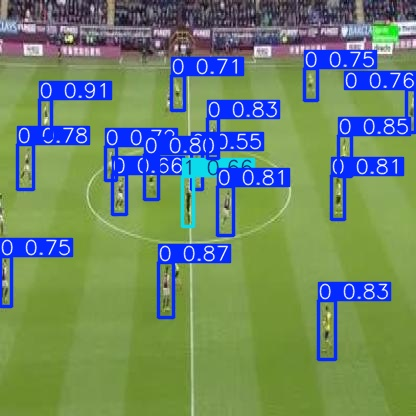

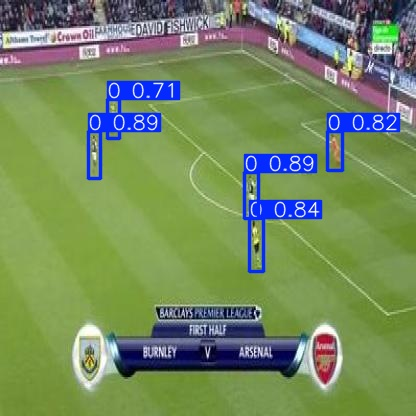

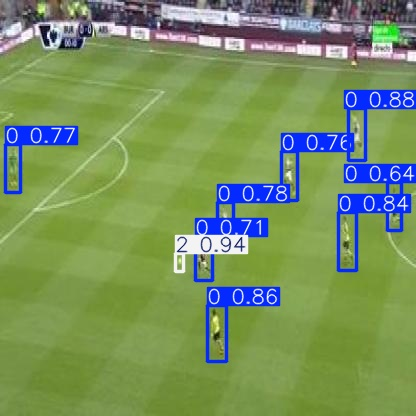

In [14]:
from IPython.display import Image, display
print(f"[예측 결과 이미지 {len(predicted_images)}개 중 일부 미리보기]")
for img_file in predicted_images[:3]:
    display(Image(filename=os.path.join(result_dir, img_file)))